![Obesity-and-Eating-Habits-header](header.png)

# Obesity Level Classification Using Eating and Lifestyle Data
## Authors
Hannah Merrill (hem2479) and Kaylee Kim (kk36778)

## 1. Project Objective

*"Obesity and Eating Habits" dataset from the UC Irvine Machine Learning Repository. The data comes from the paper 2019 "Dataset for estimation of obesity levels based on eating habits and physical condition in individuals from Colombia, Peru and Mexico," by Fabio Mendoza Palechor and Alexis De la Hoz Manotas. The dataset has estimations for the obesity levels of individuals, given eating habits and physical conditions, and contains 17 attributes and 2111 instances.*

Data Link: https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition

The goal of this project is to analyze and segment individuals based on their **lifestyle, dietary habits, and physical conditions** using the Obesity dataset. Rather than relying solely on traditional, predefined weight categories, this project leverages unsupervised machine learning techniques to uncover natural, hidden groupings within the population. 

Rather than relying on direct weight measurements, this project employs supervised machine learning, specifically a **Random Forest Multiclass Classifier** to determine how accurately we can categorize individuals into predefined weight classifications (ranging from Insufficient Weight to Obesity Type III) based solely on behavioral and physiological inputs. This project aims to identify which specific lifestyle factors are the strongest predictors of obesity, ultimately providing valuable insights for preventative healthcare.

## 2. Research Question and Prediction Task
Obesity is a complex health issue driven by a combination of genetic, dietary, and lifestyle factors. Traditional diagnostic metrics rely heavily on direct measurements like Body Mass Index (BMI). However, understanding the underlying behavioral causes, such as physical activity, dietary choices, transportation methods, and daily technology use is crucial for early intervention.  

The core problem this project addresses is: **How accurately can a person's obesity classification be predicted without knowing their actual weight, and out of these behavioral features, which serve as the strongest predictors?**

Current Expectation: Our current expectation is that the variables related to eating habits, including eating vegetables with meals (FAVC), number of main meals (FCVC), including eating food between meals (NCP), and calorie monitoring (SCC) will be the highest predictors of obesity level because food intake traditionally has the highest impact on weight of any personal habits. 

Project Evaluation: We plan to evaluate our Random Forest Classifier model using the precision, accuracy, recall, and F1 scores along with a confusion matrix. High precision, accuracy, recall, and F1 will tell us that our multiclass model is a good predictor of obesity level. Further, the confusion matrix will tell us where our model is most often inaccurate in its classifications. Using these scores, we will be able to adjust our model, fine tuning the number of estimators and variables included, to best predict obesity level. We expect this model to function well because the dataset has a large number of variables and noise.

## 3. Dataset Description

<span style='background-color: rgba(138, 43, 226, 0.1); padding: 10px; display: block; border-left: 5px solid purple;'>This project leverages a **multi-dimensional dataset** that maps **Eating Habits** with **Physical Conditions** to analyze and segment health risk profiles. The key data columns utilized are as follows:

**A. Demographic & Physiological Data (Baseline Metrics)**
Core personal and physical data serving as the baseline for an individual's profile.

- `Age` **(Age)**: The continuous age of the individual. 

- `Height` & `Weight`: Continuous measurements used to establish baseline physical size and calculate traditional metrics like BMI.

- `Gender`: Categorical variable indicating the gender of the individual.

- `family_history_with_overweight` **(Genetic Disposition)**: Binary indicator of whether a family member has suffered or suffers from overweight conditions.

**B. Dietary Habits (Eating Behaviors)**
Specific self-reported dietary choices and consumption frequencies that directly impact caloric intake and nutrition.

- `FAVC` **(Frequent High-Caloric Food)**: Binary indicator of whether the individual frequently eats high-caloric food.

- `FCVC` **(Vegetable Consumption)**: Frequency of eating vegetables in main meals.

- `NCP` **(Main Meals)**: The number of main meals the individual has daily.

- `CAEC` **(Snacking Habits)**: Frequency of consuming food between main meals.

- `CH2O` **(Water Consumption)**: Daily volume of water consumed.

- `CALC` **(Alcohol Consumption)**: Frequency of alcohol consumption.

**C. Target Variable (Weight Classification)**
The primary target or label representing the current physiological outcome, which we will use to profile our unsupervised clusters.

- `NObeyesdad` **(Obesity Level)**: The categorical weight classification (ranging from Insufficient Weight to Obesity Type III). While our model relies on unsupervised clustering, this variable helps us validate and profile the resulting segments.

**D. Contextual Features (Lifestyle Factors)**
External lifestyle and behavioral factors influencing energy expenditure and metabolic health, used to map the complete behavioral profile.

- `FAF` **(Physical Activity Frequency)**: Frequency of physical activity or exercise per week. A key indicator of active energy expenditure.

- `TUE` **(Technology Use Time)**: Time spent using technological devices daily. Serves as a primary marker for sedentary behavior.

- `MTRANS` **(Transportation Mode)**: The primary mode of transportation used (e.g., Automobile, Motorbike, Bike, Public Transportation, Walking). Used to analyze the impact of passive vs. active daily routines.

- `SMOKE` **(Smoking Habit)**: Binary indicator of whether the individual smokes.

- `SCC` **(Caloric Monitoring)**: Indicates whether the individual monitors their daily caloric intake.
</span>

## 4. Data Preprocessing and Encoding

In [1]:
# Importing necessary libraries and modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, accuracy_score

In [2]:
# Load the dataset
df = pd.read_csv('ObesityDataSet.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [3]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


## 5. Exploratory Analysis: Correlation Heatmap

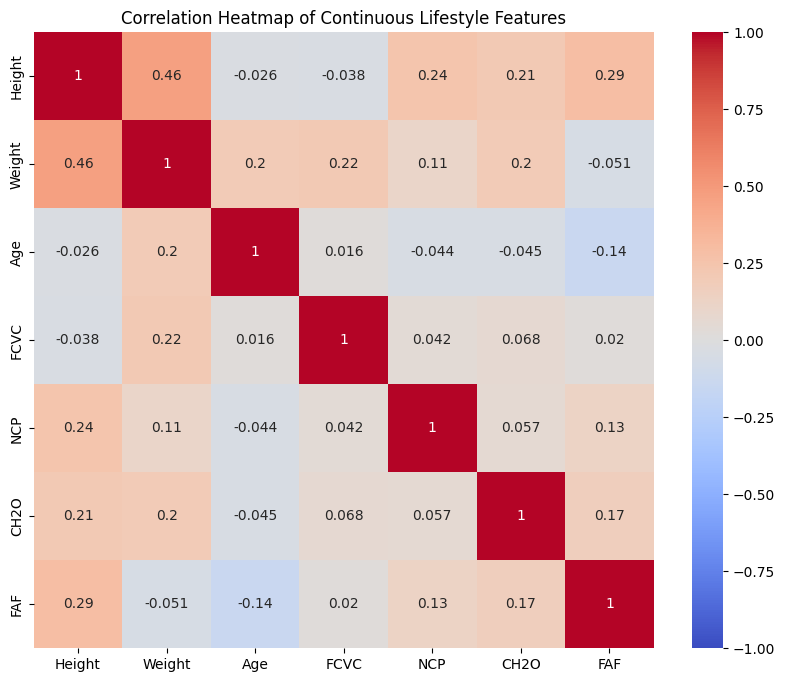

In [4]:
# Quick Data overview for numerical variables - Heat Map
numeric_cols = ['Height', 'Weight', 'Age', 'FCVC', 'NCP', 'CH2O', 'FAF']
numeric_df = df[numeric_cols]

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Continuous Lifestyle Features')
plt.show()

Taking a quick look at the correlation heatmap, we can realize that there are more variables that have the possibility to play into the Obesity Levels.

## 6. Modeling Pipeline

In [5]:
# Preserving ordinal structure for behavior-frequency features
ordinal_mapping = {
    'CAEC': {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3},
    'CALC': {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
}

target_column = 'NObeyesdad'
X = df.drop(columns=[target_column, 'Weight', 'Height']).copy()  # Exclude target and original weight/height as they factor into BMI
y = df[target_column]

for col, mapping in ordinal_mapping.items():
    X[col] = X[col].map(mapping)

# One-hot encode only nominal features
nominal_features = ['Gender', 'family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC', 'MTRANS']
X_encoded = pd.get_dummies(X, columns=nominal_features)

# Manual target encoding aligned with obesity severity progression
obesity_mapping = {
    'Insufficient_Weight': 0,
    'Normal_Weight': 1,
    'Overweight_Level_I': 2,
    'Overweight_Level_II': 3,
    'Obesity_Type_I': 4,
    'Obesity_Type_II': 5,
    'Obesity_Type_III': 6
}

class_labels = list(obesity_mapping.keys())
y_encoded = y.map(obesity_mapping)

print(X_encoded.head())
print(y.head())

    Age  FCVC  NCP  CAEC  CH2O  FAF  TUE  CALC  Gender_Female  Gender_Male  \
0  21.0   2.0  3.0     1   2.0  0.0  1.0     0           True        False   
1  21.0   3.0  3.0     1   3.0  3.0  0.0     1           True        False   
2  23.0   2.0  3.0     1   2.0  2.0  1.0     2          False         True   
3  27.0   3.0  3.0     1   2.0  2.0  0.0     2          False         True   
4  22.0   2.0  1.0     1   2.0  0.0  0.0     1          False         True   

   ...  FAVC_yes  SMOKE_no  SMOKE_yes  SCC_no  SCC_yes  MTRANS_Automobile  \
0  ...     False      True      False    True    False              False   
1  ...     False     False       True   False     True              False   
2  ...     False      True      False    True    False              False   
3  ...     False      True      False    True    False              False   
4  ...     False      True      False    True    False              False   

   MTRANS_Bike  MTRANS_Motorbike  MTRANS_Public_Transportation  MTRA

In [6]:
# 3. Splitting data into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Scale continuous numeric features after split to avoid leakage
numeric_cols = ['Age', 'FCVC', 'NCP', 'CH2O', 'FAF']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [7]:
# 4. Baseline Random Forest with 5-fold cross-validation
rf_baseline = RandomForestClassifier(random_state=123)
cv_scores = cross_val_score(rf_baseline, X_encoded, y_encoded, cv=5, scoring='accuracy')

print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Cross-validation accuracy scores: [0.57683215 0.8957346  0.88625592 0.89810427 0.91232227]
Mean CV accuracy: 0.8338 (+/- 0.1288)


In [8]:
# 5. Hyperparameter tuning with GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=123),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
print("Best Random Forest parameters:", grid_search.best_params_)
print(f"Best CV score from GridSearchCV: {grid_search.best_score_:.4f}")

Best Random Forest parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score from GridSearchCV: 0.8466


In [9]:
# 4. Initializing and Training the Random Forest Method
model = best_model
model.fit(X_train_scaled, y_train)

# 5. Predicting obesity level based on input features
y_pred = model.predict(X_test_scaled)

# Calculating and printing the accuracy, precision, recall, and F1 of the model
score = model.score(X_test_scaled, y_test)
print(f"Accuracy of Classifier is: {score:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_labels))

Accuracy of Classifier is: 0.84

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.92      0.91      0.92        54
      Normal_Weight       0.62      0.78      0.69        58
 Overweight_Level_I       0.77      0.71      0.74        58
Overweight_Level_II       0.83      0.76      0.79        58
     Obesity_Type_I       0.84      0.81      0.83        70
    Obesity_Type_II       0.90      0.92      0.91        60
   Obesity_Type_III       1.00      0.97      0.98        65

           accuracy                           0.84       423
          macro avg       0.84      0.84      0.84       423
       weighted avg       0.84      0.84      0.84       423



In [10]:
# 6. Train and evaluate AdaBoost for comparison
ada_model = AdaBoostClassifier(random_state=123)
ada_model.fit(X_train_scaled, y_train)

ada_pred = ada_model.predict(X_test_scaled)
ada_score = accuracy_score(y_test, ada_pred)

print(f"AdaBoost accuracy: {ada_score:.2f}")
print("\nAdaBoost Classification Report:")
print(classification_report(y_test, ada_pred, target_names=class_labels))

AdaBoost accuracy: 0.47

AdaBoost Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.61      0.56      0.58        54
      Normal_Weight       0.43      0.28      0.34        58
 Overweight_Level_I       0.31      0.47      0.37        58
Overweight_Level_II       0.39      0.16      0.22        58
     Obesity_Type_I       0.35      0.47      0.40        70
    Obesity_Type_II       0.43      0.33      0.38        60
   Obesity_Type_III       0.75      0.98      0.85        65

           accuracy                           0.47       423
          macro avg       0.47      0.46      0.45       423
       weighted avg       0.47      0.47      0.45       423



### 6.6 Model Comparison: Random Forest vs AdaBoost

After training and evaluating both models on the same scaled train/test split, the tuned **Random Forest clearly outperformed AdaBoost**. Random Forest reached an accuracy of 0.84, while AdaBoost reached 0.47, and Random Forest also showed much stronger class-level precision, recall, and F1 scores overall. This indicates that Random Forest is far better at separating obesity classes in this multiclass setting, especially across adjacent severity boundaries. 

Based on these results, **Random Forest** should be selected as the final model for interpretation and reporting.

## 7. Model Interpretation: Feature Importance

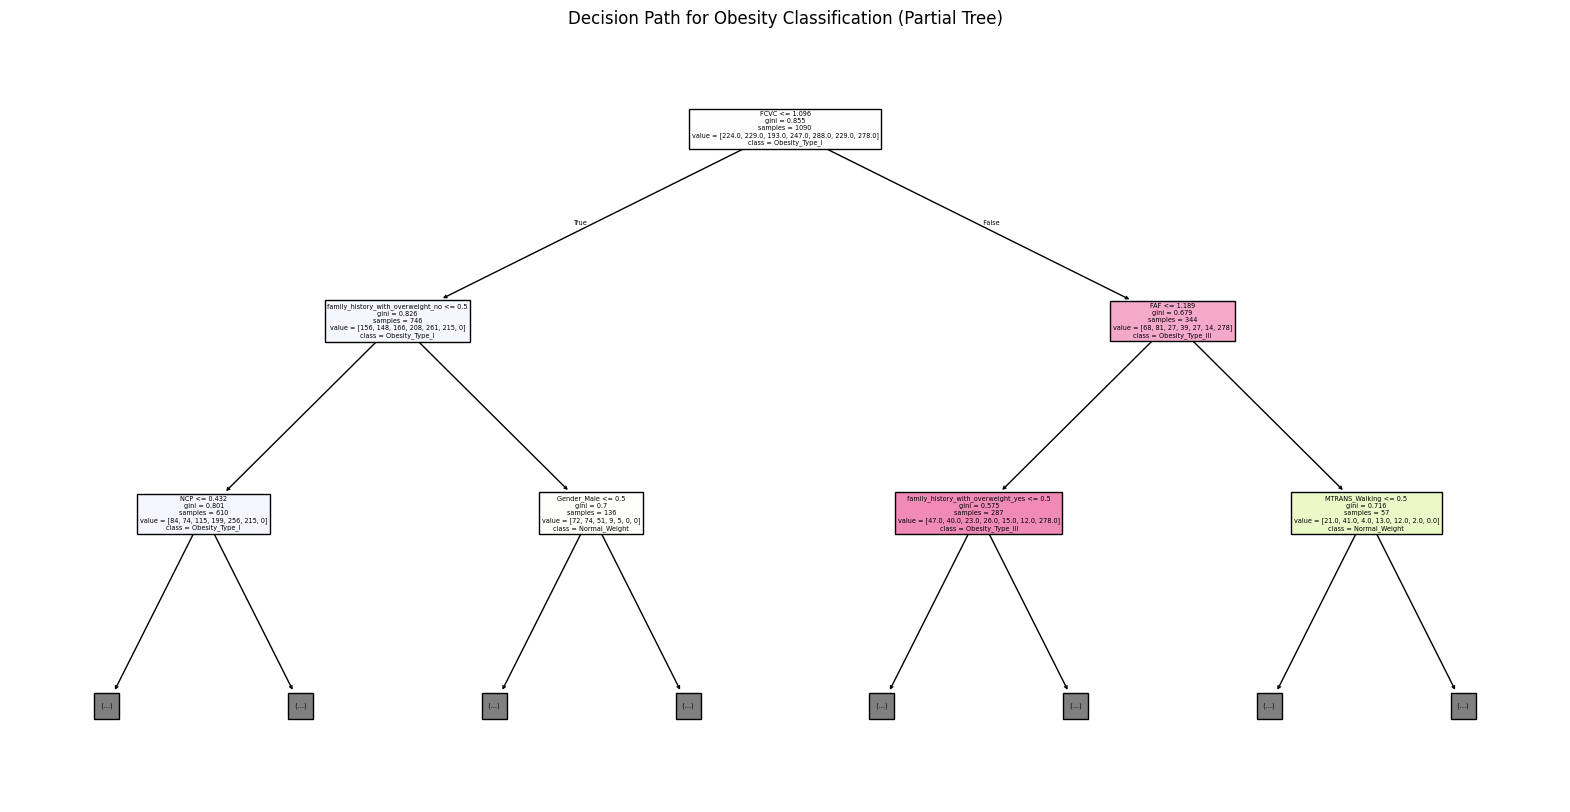

In [11]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

chosen_tree = model.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(chosen_tree, feature_names=X_encoded.columns, class_names=class_labels, filled=True, max_depth=2)
plt.title("Decision Path for Obesity Classification (Partial Tree)")
plt.show()

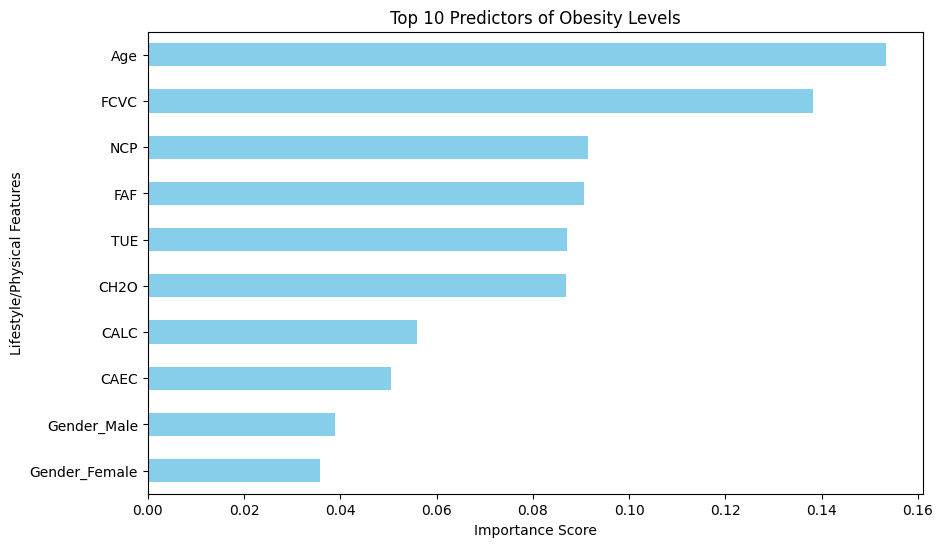

In [12]:
# Calculating feature importance
importances = pd.Series(model.feature_importances_, index=X_encoded.columns)
importances = importances.sort_values(ascending=False).head(10) # Top 10 features

# Plotting feature importance
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='skyblue')
plt.title("Top 10 Predictors of Obesity Levels")
plt.xlabel("Importance Score")
plt.ylabel("Lifestyle/Physical Features")
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()

The feature-importance results show that Age is the strongest single predictor, but multiple lifestyle and behavior variables also rank highly, including `FCVC`, `NCP`, `FAF`, `TUE`, and `CH2O`. Ordinal behavior-frequency variables (`CALC` and `CAEC`) contribute meaningful signal as well, while gender-related features are present but less dominant. 

Overall, this suggests obesity classification in this dataset is influenced by both **baseline demographic factors** and **modifiable daily habits**, with lifestyle variables *providing important actionable insight*.

## 8. Error Analysis: Confusion Matrix

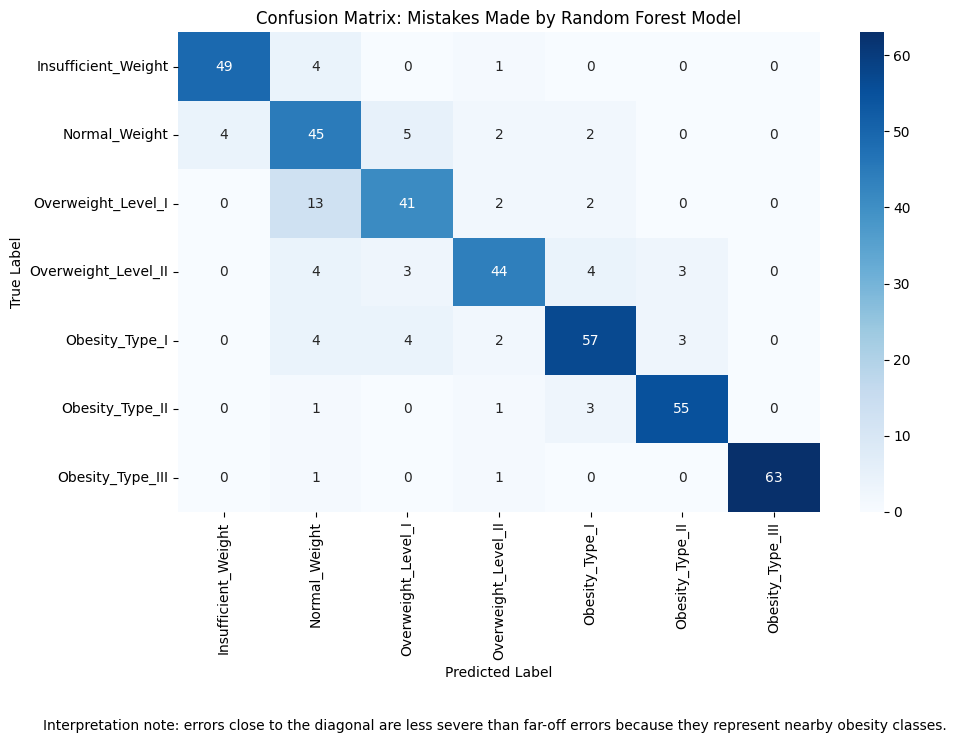

In [13]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Mistakes Made by Random Forest Model')
plt.figtext(
    0.5,
    -0.05,
    'Interpretation note: errors close to the diagonal are less severe than far-off errors because they represent nearby obesity classes.',
    ha='center',
    fontsize=10
)
plt.tight_layout()
plt.show()

With ordinal target encoding, the confusion-matrix axes now progress logically from *Insufficient Weight* to *Obesity Type III*. Most errors are concentrated near the **main diagonal**, which is desirable because those mistakes usually represent **neighboring severity classes** (for example, predicting Overweight Level II instead of Obesity Type I). Far-from-diagonal errors are less frequent and represent larger severity mismatches. This pattern suggests the model generally captures obesity progression structure even when it is not perfectly accurate.

## 9. Final Performance Summary

Model tuning and evaluation are now substantially stronger than a single-split approach. Baseline 5-fold cross-validation produced a mean accuracy of **0.8338**, and GridSearchCV improved the best cross-validated score to **0.8466** with parameters `max_depth=20`, `min_samples_split=2`, and `n_estimators=200`. 

This confirms that hyperparameter tuning produced a measurable gain. At the same time, fold-to-fold variability suggests some sensitivity to data partitioning, so results should be interpreted as strong overall performance with moderate split dependence.

References: 
* Dataset Webpage: https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition
* Original Paper DOI: https://doi.org/10.1016/j.dib.2019.104344 
* Random Forest Classifier Description: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html